In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_pickle("../data/clean/airbnb_processed2.pkl")

In [3]:
df.head()

,lat,long,Construction year,price,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365,...,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodrow,neighbourhood_Woodside,instant_bookable_True,cancellation_policy_moderate,cancellation_policy_strict,room type_Hotel room,room type_Private room,room type_Shared room
0,40.64749,-73.97237,2020.0,966.0,10.0,9.0,0.21,4.0,6.0,286.0,...,False,False,False,False,False,False,True,False,True,False
1,40.75362,-73.98377,2007.0,142.0,30.0,45.0,0.38,4.0,2.0,228.0,...,False,False,False,False,False,True,False,False,False,False
2,40.80902,-73.94190,2005.0,620.0,3.0,0.0,0.00,5.0,1.0,352.0,...,False,False,False,False,True,False,False,False,True,False
3,40.68514,-73.95976,2005.0,368.0,30.0,270.0,4.64,4.0,1.0,322.0,...,False,False,False,False,True,True,False,False,False,False
4,40.79851,-73.94399,2009.0,204.0,10.0,9.0,0.10,3.0,1.0,289.0,...,False,False,False,False,False,True,False,False,False,False


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 98021 entries, 0 to 102057
Columns: 245 entries, lat to room type_Shared room
dtypes: bool(235), float64(10)
memory usage: 30.2 MB


In [5]:
df.columns

Index(['lat', 'long', 'Construction year', 'price', 'minimum nights',
       'number of reviews', 'reviews per month', 'review rate number',
       'calculated host listings count', 'availability 365',
       ...
       'neighbourhood_Woodhaven', 'neighbourhood_Woodlawn',
       'neighbourhood_Woodrow', 'neighbourhood_Woodside',
       'instant_bookable_True', 'cancellation_policy_moderate',
       'cancellation_policy_strict', 'room type_Hotel room',
       'room type_Private room', 'room type_Shared room'],
      dtype='str', length=245)

## Feature Engineering

- d'apres ces colonnes qu'on a eu on peut combiner par long and llat pour avoir un dim des airbnb annonce les plus proche du time square (centre ville)
- da'pres une petite

In [6]:
#lat et long du time square
lat_center = 40.7589
long_center = -73.9851

df["distance_center"] = np.sqrt(
    (df["lat"] - lat_center)**2 +
    (df["long"] - long_center)**2
)

- puis on mais directement l'age des la construction des appartements dirrectement

In [7]:
current_year = 2026
df["property_age"] = current_year - df["Construction year"]

In [8]:
df = df.drop(columns=["Construction year"])

- cette log_price vas nous donner des prix minimiser pour que notre model de regression ne sera pas influencer par les grandes prix et ne dois etre normalise car ca serais notre predictions du projet
- log_price=log(1+price)
On utilise log1p pour éviter les problèmes mathématiques si la valeur était 0.

In [9]:
df["log_price"] = np.log1p(df["price"])


In [10]:
df[["distance_center", "property_age", "log_price"]].head()

,distance_center,property_age,log_price
0,0.112135,6.0,6.874198
1,0.005445,19.0,4.962845
2,0.066168,21.0,6.431331
3,0.077991,21.0,5.910797
4,0.057088,17.0,5.323010


+ ici on a supprimer price car on aura plus besoin maintenant on a log_price qui nous le ln(prix)apres le teste pour revenir le prix a origine on vas utiliser expo(y_test)-1 puisque la fonction au debut on ajoute le 1 pour les valeurs qui egale a 0

In [11]:
X = df.drop(columns=["price", "log_price"])
y = df["log_price"]

+ ici on vas spliter notre data 0.8 pour entrainement ,0.2 pour tester1

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
print(X_train.shape)
print(X_test.shape)


(78416, 245)
(19605, 245)


In [14]:
X_train.head()

,lat,long,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365,host_identity_verified_unknown,host_identity_verified_verified,...,neighbourhood_Woodrow,neighbourhood_Woodside,instant_bookable_True,cancellation_policy_moderate,cancellation_policy_strict,room type_Hotel room,room type_Private room,room type_Shared room,distance_center,property_age
46618,40.81144,-73.94386,3.0,0.0,0.00,2.0,3.0,244.0,False,True,...,False,False,True,False,True,False,True,False,0.066792,8.0
15239,40.74369,-73.99571,2.0,5.0,0.14,4.0,1.0,57.0,False,True,...,False,False,True,False,True,False,False,False,0.018545,16.0
75007,40.67721,-73.91404,30.0,0.0,0.00,4.0,5.0,317.0,False,True,...,False,False,False,False,True,False,True,False,0.108272,10.0
74998,40.65813,-73.95788,1.0,0.0,0.00,4.0,1.0,0.0,False,True,...,False,False,False,True,False,False,True,False,0.104382,7.0
71780,40.67763,-74.00108,59.0,17.0,0.49,1.0,1.0,58.0,False,True,...,False,False,False,False,False,False,False,False,0.082826,13.0


+ maintenant on standarise les donne de x_train

In [15]:
continuous_cols = [
    "lat",
    "long",
    "minimum nights",
    "number of reviews",
    "reviews per month",
    "review rate number",
    "calculated host listings count",
    "availability 365",
    "distance_center",
    "property_age"
]


In [16]:
scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])


In [17]:
print(X_train[continuous_cols].mean())
print(X_train[continuous_cols].std())

lat                               5.046533e-14
long                              1.244987e-13
minimum nights                   -2.718359e-18
number of reviews                 4.893046e-17
reviews per month                 1.123588e-16
review rate number               -7.248957e-17
calculated host listings count   -9.786092e-18
availability 365                 -5.183004e-17
distance_center                  -1.957218e-16
property_age                     -2.065953e-17
dtype: float64
lat                               1.000006
long                              1.000006
minimum nights                    1.000006
number of reviews                 1.000006
reviews per month                 1.000006
review rate number                1.000006
calculated host listings count    1.000006
availability 365                  1.000006
distance_center                   1.000006
property_age                      1.000006
dtype: float64


In [18]:
X_train.head()

,lat,long,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365,host_identity_verified_unknown,host_identity_verified_verified,...,neighbourhood_Woodrow,neighbourhood_Woodside,instant_bookable_True,cancellation_policy_moderate,cancellation_policy_strict,room type_Hotel room,room type_Private room,room type_Shared room,distance_center,property_age
46618,1.489217,0.108710,-0.171776,-0.557067,-0.723701,-1.008305,-0.154719,0.843976,False,True,...,False,False,True,False,True,False,True,False,-0.148469,-0.955322
15239,0.279501,-0.931937,-0.205284,-0.454373,-0.637532,0.557135,-0.216136,-0.596044,False,True,...,False,False,True,False,True,False,False,False,-1.138507,0.432789
75007,-0.907538,0.707208,0.732940,-0.557067,-0.723701,0.557135,-0.093303,1.406123,False,True,...,False,False,False,False,True,False,True,False,0.702698,-0.608294
74998,-1.248223,-0.172676,-0.238792,-0.557067,-0.723701,0.557135,-0.216136,-1.034981,False,True,...,False,False,False,True,False,False,True,False,0.622871,-1.128836
71780,-0.900039,-1.039715,1.704673,-0.207907,-0.422108,-1.791026,-0.216136,-0.588343,False,True,...,False,False,False,False,False,False,False,False,0.180551,-0.087753


### 1. Choix du modèle

- on cherche a predire le y = log_price donc La nature du problème est une **régression**, car l’objectif est de predire une variable continue representant le prix d’un logement Airbnb


Afin d’identifier le modèle le plus performant, plusieurs algorithmes de régression ont été testés et comparés à l’aide de métriques adaptées telles que le R² et le RMSE. Cette approche permet de sélectionner le modèle offrant la meilleure capacité de généralisation.

#### Modèle 1 — Linear Regression

+ puisqu'on avait un problem d'execution du premier modele linear regression car on a avait des nan dand la dataset xtrain est xtest on la supprimer

In [19]:
print("NaN dans X_train :", X_train.isnull().sum().sum())
print("NaN dans X_test  :", X_test.isnull().sum().sum())

NaN dans X_train : 0
NaN dans X_test  : 0


In [20]:
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])


Series([], dtype: int64)


In [21]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

In [22]:
X_train.isnull().sum().sum()

np.int64(0)

In [23]:
print("NaN X_train:", X_train.isnull().sum().sum())
print("NaN X_test :", X_test.isnull().sum().sum())

print("\nColonnes NaN dans X_train:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("\nColonnes NaN dans X_test:")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])


NaN X_train: 0
NaN X_test : 0

Colonnes NaN dans X_train:
Series([], dtype: int64)

Colonnes NaN dans X_test:
Series([], dtype: int64)


In [24]:
# Supprimer lignes NaN dans X_train et réaligner y_train
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

# Supprimer lignes NaN dans X_test et réaligner y_test
X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]


In [25]:
print("NaN X_train:", X_train.isnull().sum().sum())
print("NaN X_test :", X_test.isnull().sum().sum())

NaN X_train: 0
NaN X_test : 0


on teste maintenant la regression lineaire apres supression des cellules nan

In [26]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_log = lin_reg.predict(X_test)   # prédiction sur log_price

on fait un test pour la celule 6 si la regression a bien etait appliquer

In [27]:
print(y_pred_log[:5])

[6.27558886 6.22320824 6.23077274 6.24240175 6.23710021]


+ resultat de test sur le log_price

In [28]:
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2 = r2_score(y_test, y_pred_log)

print(">>> Linear Regression (log_price)")
print(f"MAE  : {mae_log:.4f}")
print(f"RMSE : {rmse_log:.4f}")
print(f"R²   : {r2:.4f}")

>>> Linear Regression (log_price)
MAE  : 0.5809
RMSE : 0.7200
R²   : -0.0020


+ resultat du test sur prix reelle apres convertion

In [29]:
y_test_price = np.expm1(y_test)
y_pred_price = np.expm1(y_pred_log)

mae_price = mean_absolute_error(y_test_price, y_pred_price)
rmse_price = np.sqrt(mean_squared_error(y_test_price, y_pred_price))

print("\n<<< Performance en prix réel >>>")
print(f"MAE  : {mae_price:.2f}")
print(f"RMSE : {rmse_price:.2f}")



<<< Performance en prix réel >>>
MAE  : 296.21
RMSE : 350.02


##### La régression linéaire présente un R² proche de zéro, indiquant que le modèle n’explique pas la variance du prix. L’erreur moyenne absolue est élevée (~298$), suggérant que la relation entre les variables explicatives et le prix n’est pas purement linéaire. 

#### 2-Ridge Regression

In [30]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)  # valeur par défaut raisonnable
ridge.fit(X_train, y_train)

y_pred_log_ridge = ridge.predict(X_test)


In [31]:
mae_log_ridge = mean_absolute_error(y_test, y_pred_log_ridge)
rmse_log_ridge = np.sqrt(mean_squared_error(y_test, y_pred_log_ridge))
r2_ridge = r2_score(y_test, y_pred_log_ridge)

print(">>> Ridge Regression (log_price)")
print(f"MAE  : {mae_log_ridge:.4f}")
print(f"RMSE : {rmse_log_ridge:.4f}")
print(f"R²   : {r2_ridge:.4f}")

>>> Ridge Regression (log_price)
MAE  : 0.5808
RMSE : 0.7199
R²   : -0.0016


In [32]:
y_pred_price_ridge = np.expm1(y_pred_log_ridge)
y_test_price = np.expm1(y_test)

mae_price_ridge = mean_absolute_error(y_test_price, y_pred_price_ridge)
rmse_price_ridge = np.sqrt(mean_squared_error(y_test_price, y_pred_price_ridge))

print("\n<<< Ridge - Performance en prix réel >>>")
print(f"MAE  : {mae_price_ridge:.2f}")
print(f"RMSE : {rmse_price_ridge:.2f}")


<<< Ridge - Performance en prix réel >>>
MAE  : 296.18
RMSE : 349.98


+ Les performances de la régression Ridge sont similaires à celles de la régression linéaire. Cela suggère que la régularisation ne permet pas d’améliorer significativement le modèle, indiquant que la relation entre les variables explicatives et le prix n’est pas purement linéair

### 3-Random Forest Regressor

In [33]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_log_rf = rf.predict(X_test)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_log_rf = mean_absolute_error(y_test, y_pred_log_rf)
rmse_log_rf = np.sqrt(mean_squared_error(y_test, y_pred_log_rf))
r2_rf = r2_score(y_test, y_pred_log_rf)

print(">>> Random Forest (log_price)")
print(f"MAE  : {mae_log_rf:.4f}")
print(f"RMSE : {rmse_log_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

>>> Random Forest (log_price)
MAE  : 0.4395
RMSE : 0.5813
R²   : 0.3470


In [35]:
y_test_price = np.expm1(y_test)
y_pred_price_rf = np.expm1(y_pred_log_rf)

mae_price_rf = mean_absolute_error(y_test_price, y_pred_price_rf)
rmse_price_rf = np.sqrt(mean_squared_error(y_test_price, y_pred_price_rf))

print("\n<<< Random Forest - Performance en prix réel >>>")
print(f"MAE  : {mae_price_rf:.2f}")
print(f"RMSE : {rmse_price_rf:.2f}")


<<< Random Forest - Performance en prix réel >>>
MAE  : 225.64
RMSE : 289.89


### interpretation des resultats 

In [36]:
print("===== COMPARAISON DES MODÈLES =====")
print(f"Linear  | R²: {r2:.4f} | RMSE($): {rmse_price:.2f}")
print(f"Ridge   | R²: {r2_ridge:.4f} | RMSE($): {rmse_price_ridge:.2f}")
print(f"RF      | R²: {r2_rf:.4f} | RMSE($): {rmse_price_rf:.2f}")


===== COMPARAISON DES MODÈLES =====
Linear  | R²: -0.0020 | RMSE($): 350.02
Ridge   | R²: -0.0016 | RMSE($): 349.98
RF      | R²: 0.3470 | RMSE($): 289.89


Les résultats montrent que le modèle Random Forest surpasse significativement les modèles linéaires. Cela indique que la relation entre les variables explicatives et le prix est non linéaire et complexe. Le Random Forest, capable de capturer des interactions non linéaires, offre donc de meilleures performances prédictives

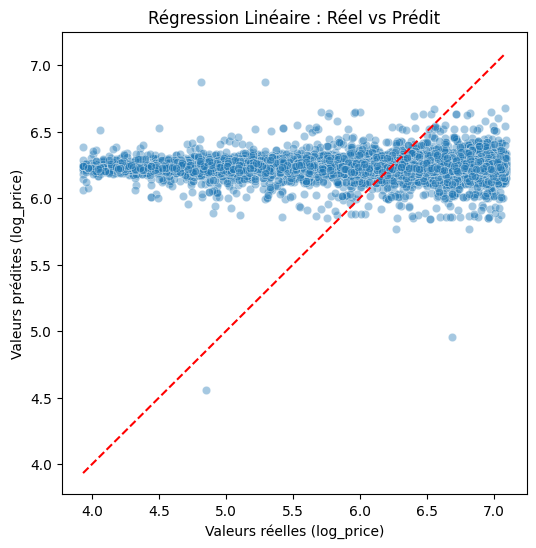

In [37]:

plt.figure(figsize=(6,6))

sns.scatterplot(x=y_test, y=y_pred_log, alpha=0.4)

# Ligne parfaite y = x
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Valeurs réelles (log_price)")
plt.ylabel("Valeurs prédites (log_price)")
plt.title("Régression Linéaire : Réel vs Prédit")
plt.show()

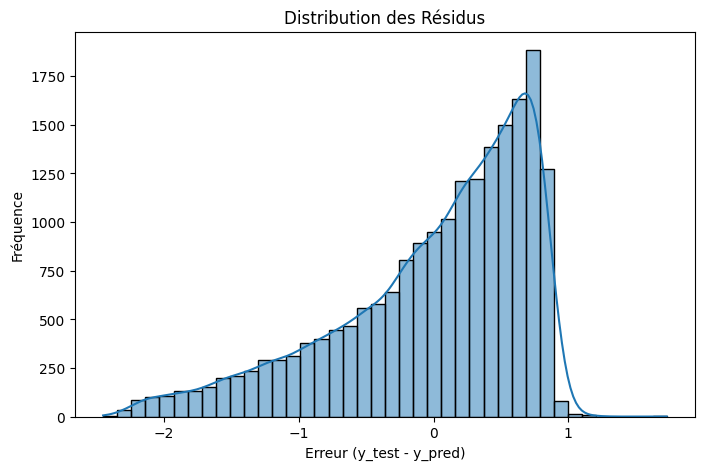

In [38]:
residuals = y_test - y_pred_log

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=40, kde=True)

plt.title("Distribution des Résidus")
plt.xlabel("Erreur (y_test - y_pred)")
plt.ylabel("Fréquence")
plt.show()


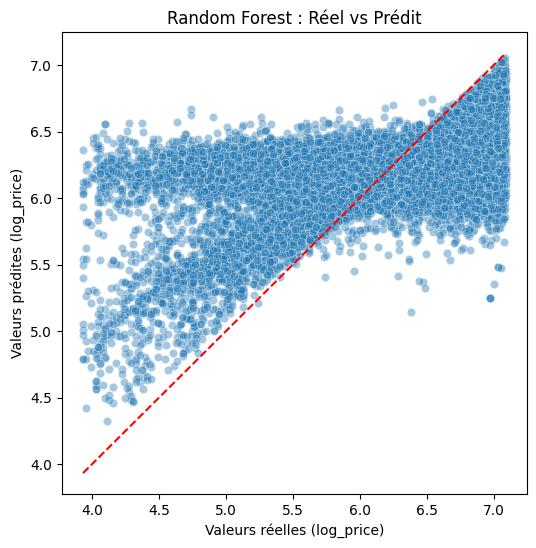

In [39]:
plt.figure(figsize=(6,6))

sns.scatterplot(x=y_test, y=y_pred_log_rf, alpha=0.4)

# Ligne parfaite y = x
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Valeurs réelles (log_price)")
plt.ylabel("Valeurs prédites (log_price)")
plt.title("Random Forest : Réel vs Prédit")
plt.show()

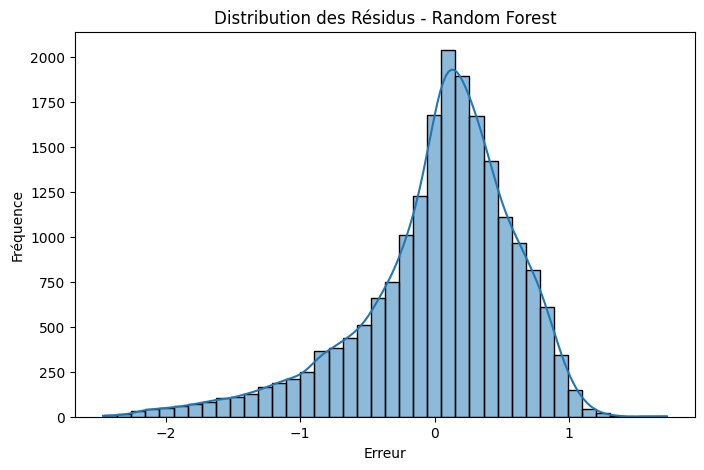

In [40]:
residuals_rf = y_test - y_pred_log_rf

plt.figure(figsize=(8,5))
sns.histplot(residuals_rf, bins=40, kde=True)

plt.title("Distribution des Résidus - Random Forest")
plt.xlabel("Erreur")
plt.ylabel("Fréquence")
plt.show()

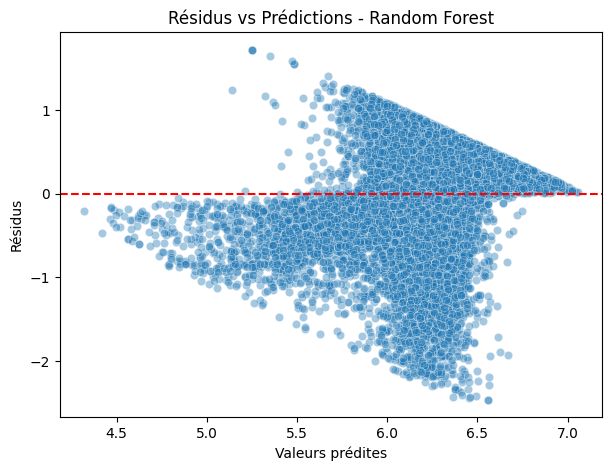

In [41]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_pred_log_rf, y=residuals_rf, alpha=0.4)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs Prédictions - Random Forest")
plt.show()